<a href="https://colab.research.google.com/github/caviteri/Ciencia-de-Datos-2026/blob/main/Ciencia_de_Datos_Semana_07_Filtro_de_Wiener.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Taller Práctico: Predicción con Filtro de Wiener**

Maestría en Ingeniería Electrónica

Universidad de Nariño

Introducción a la Ciencia de Datos

Instructor: Carlos Andrés Viteri Mera

En este cuaderno se estudia el diseño de un predictor lineal óptimo conocido como Filtro de Wiener. El objetivo es minimizar el error cuadrático medio (MMSE) de las predicciones (estimaciones) del valor futuro de una serie de tiempo con base en sus valores pasados. El filtro se diseña al resolver las ecuaciones normales de Wiener-Hopf ($R_x​a=r_x$​) utilizando la matriz de autocorrelación $R_x$ y el vector de correlación cruzada $r_x$. Se aplicará este ejemplo a los rendimientos del S&P 500.

In [1]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.linalg as la
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## **1. Obtención y Normalización de Datos**
Se descargan los últimos 10 años del índice S&P 500. Se calculan los rendimientos diarios porcentuales y se resta la media empírica para garantizar un proceso de media cero.

In [2]:
# 1. Descargar 10 años de datos del S&P 500
data = yf.download('^GSPC', period='10y')
precios = data['Close'].squeeze()

# 2. Calcular rendimientos y normalizar a media cero
rendimientos = precios.pct_change().dropna() * 100
media_rendimientos = rendimientos.mean()
x = (rendimientos - media_rendimientos).values
N = len(x)

print(f"Total de muestras (días): {N}")

[*********************100%***********************]  1 of 1 completed

Total de muestras (días): 2514


## **2. Correlación Cruzada y Cálculo del Filtro de Wiener**
Para un filtro predictor de orden $p$, estimamos la secuencia de autocorrelación $r_x​(n)$.

La matriz $R_x$​ (de tamaño $p\times p$) contiene las autocorrelaciones de los retardos $0$ a $p−1$.

El vector $r_x$​ contiene la correlación cruzada entre $x(n)$ y el valor futuro $x(n+1)$, correspondiente a los retardos $1$ a $p$. Resolvemos el sistema lineal para hallar los coeficientes óptimos $a$.

In [3]:
p = 90 # Orden del filtro (se usan 90 retardos para predecir el siguiente valor)

# Función para estimar la autocorrelación empírica
def estimar_autocorrelacion(x, max_lag):
    r = np.zeros(max_lag + 1)
    for k in range(max_lag + 1):
        r[k] = np.mean(x[k:] * x[:len(x)-k])
    return r

# Estimamos hasta el retardo p
r_x_completo = estimar_autocorrelacion(x, p)

# Matriz de autocorrelación Toeplitz (R_x)
R_matriz = la.toeplitz(r_x_completo[:p])

# Vector de correlación cruzada con el paso futuro (r_x)
r_vector = r_x_completo[1:p+1]

# Resolver ecuaciones de Wiener-Hopf: R_x * a = r_x
coeficientes_wiener = np.linalg.solve(R_matriz, r_vector)

print("Coeficientes del Filtro de Wiener (a_1, ..., a_p):")
print(np.round(coeficientes_wiener, 4))

Coeficientes del Filtro de Wiener (a_1, ..., a_p):
[-0.1031  0.0506 -0.0207 -0.0705  0.0208 -0.0556  0.08   -0.0681  0.0883
 -0.0094 -0.003  -0.0066 -0.0387 -0.007  -0.0369  0.0035  0.0021 -0.0026
 -0.0182  0.0029  0.0088 -0.0572 -0.0318 -0.0036 -0.0366 -0.0518  0.0269
  0.019  -0.0106 -0.0257 -0.0189 -0.0003 -0.0173 -0.0102  0.007   0.0288
 -0.0308 -0.0033  0.0075 -0.0136 -0.0468  0.0204 -0.0155 -0.0263 -0.0019
 -0.0298  0.0174  0.0024 -0.0207  0.0151  0.0166 -0.0113  0.0114 -0.0168
 -0.0272 -0.02   -0.0215 -0.0034 -0.0152 -0.0235  0.0144 -0.0461  0.0155
  0.0064 -0.0008  0.0046 -0.0027  0.0034  0.0184 -0.0057  0.0022  0.0139
  0.0163  0.0004 -0.0221 -0.0078 -0.0184 -0.0229 -0.0013 -0.0199  0.0108
  0.0381 -0.0096 -0.0384 -0.0068 -0.0073  0.0369  0.0047 -0.0222 -0.0035]


## **3. Predicción de las Siguientes 20 Muestras**
Se utiliza el filtro de Wiener para predecir iterativamente los próximos 20 días de rendimientos. Cada nueva predicción se alimentará de las predicciones inmediatamente anteriores para avanzar en el tiempo.

In [4]:
dias_prediccion = 20
x_pred_futuro = np.zeros(dias_prediccion)

# Tomamos los últimos 'p' días reales como condición inicial
historia_reciente = list(x[-p:])

for i in range(dias_prediccion):
    # El producto punto invierte el orden para alinear a_1 con x(n), a_2 con x(n-1)...
    pred_actual = np.dot(coeficientes_wiener, historia_reciente[-p:][::-1])
    x_pred_futuro[i] = pred_actual
    historia_reciente.append(pred_actual)

print("Rendimientos predichos (media cero):")
print(np.round(x_pred_futuro, 4))

Rendimientos predichos (media cero):
[-0.0489  0.1368 -0.0394 -0.0976  0.2904 -0.0561  0.0458 -0.0697  0.2355
 -0.1907  0.2045  0.0083 -0.2726 -0.0577 -0.1877  0.3284 -0.0548 -0.2137
 -0.2371  0.0341]


## **5. Reconstrucción a Precios y Visualización**
Se convierte la secuencia de retornos predichos nuevamente a su escala real sumando la media histórica. Luego, reconstruiremos los precios usando la fórmula de interés compuesto y los graficaremos junto con los precios reales de los últimos 3 meses (aprox. 60 días de negociación).

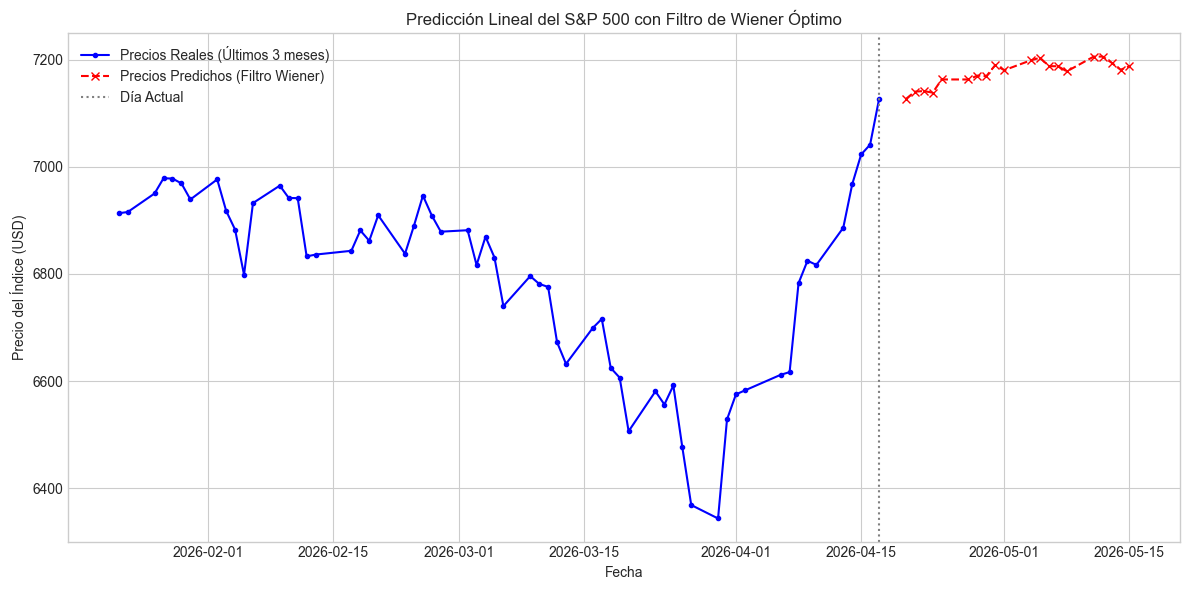

In [5]:
# 1. Devolver la media a los rendimientos predichos
rendimientos_pred_reales = x_pred_futuro + media_rendimientos

# 2. Convertir a precios proyectados partiendo del último precio real
precio_actual = precios.iloc[-1]
precios_proyectados = precio_actual * (1 + rendimientos_pred_reales / 100).cumprod()

# 3. Preparar datos para gráfica (últimos 3 meses = 60 días hábiles)
dias_historia = 60
precios_recientes = precios.iloc[-dias_historia:]
fechas_recientes = precios.index[-dias_historia:]

# Crear un índice de fechas futuras (solo para visualización continua)
fechas_futuras = pd.date_range(start=fechas_recientes[-1] + pd.Timedelta(days=1), periods=dias_prediccion, freq='B')

plt.figure(figsize=(12, 6))
plt.plot(fechas_recientes, precios_recientes, label='Precios Reales (Últimos 3 meses)', color='blue', marker='.')
plt.plot(fechas_futuras, precios_proyectados, label='Precios Predichos (Filtro Wiener)', color='red', marker='x', linestyle='--')

plt.title('Predicción Lineal del S&P 500 con Filtro de Wiener Óptimo')
plt.xlabel('Fecha')
plt.ylabel('Precio del Índice (USD)')
plt.axvline(fechas_recientes[-1], color='gray', linestyle=':', label='Día Actual')
plt.legend()
plt.tight_layout()
plt.show()

## **Reto**
Utilice el código anterior como referencia para predecir los valores futuros de alguna serie de tiempo WSS de su interés. En el caso de que la serie no sea WSS, aplique algunas de las transformaciones estudiadas anteriormente.

[*********************100%***********************]  1 of 1 completed


Prueba ADF — Precios crudos EUR/USD:
  Estadístico: -2.2948  |  p-value: 1.7364e-01
  → NO estacionarios. Aplicamos rendimientos porcentuales.

Prueba ADF — Rendimientos EUR/USD (media cero):
  Estadístico: -51.2868  |  p-value: 0.0000e+00
  → Rechazamos H0. La serie ES estacionaria (WSS). ✓

Total de muestras: 2601 días


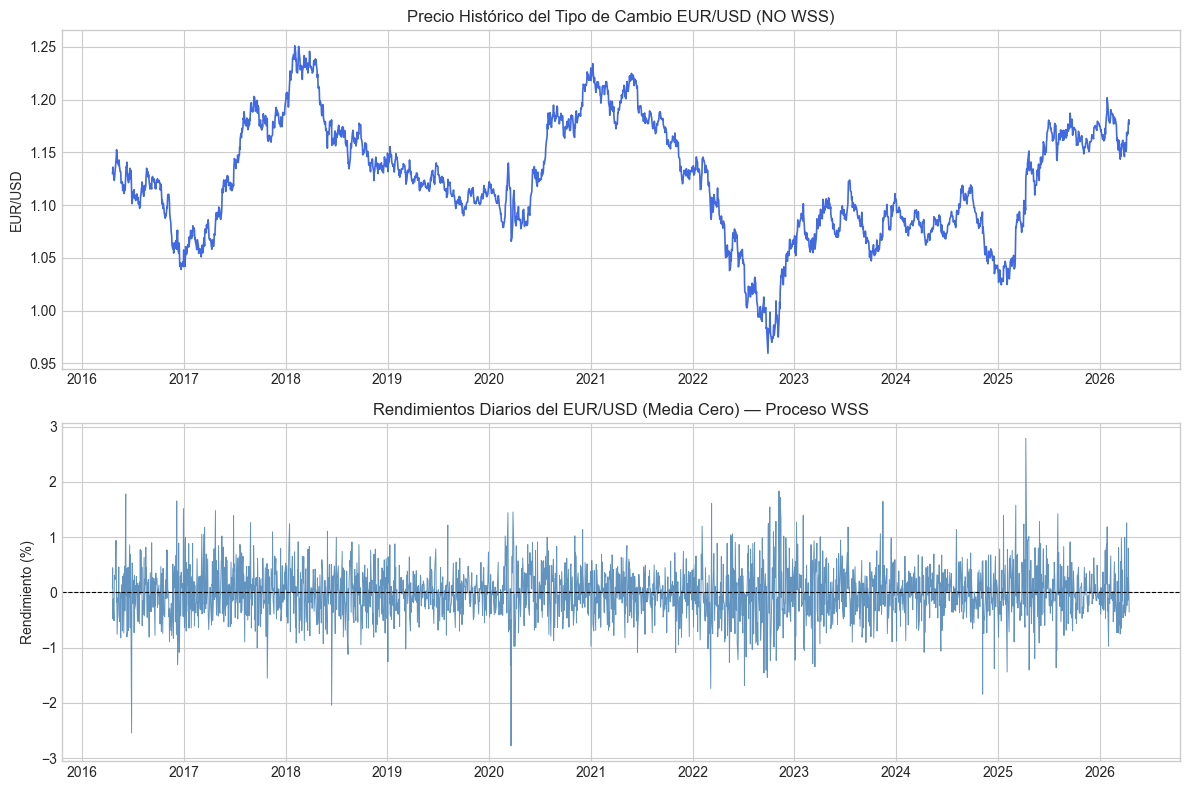

In [6]:
# ============================================================
# Reto – Descarga y preparación: Tipo de Cambio EUR/USD
# ============================================================
from statsmodels.tsa.stattools import adfuller

# Los precios crudos del EUR/USD no son WSS.
# Se trabaja con los rendimientos porcentuales diarios centrados en la media.

data_eur    = yf.download('EURUSD=X', period='10y')
precios_eur = data_eur['Close'].squeeze().dropna()

# Verificar que los precios crudos NO son WSS
adf_eur_crudo = adfuller(precios_eur)
print("Prueba ADF — Precios crudos EUR/USD:")
print(f"  Estadístico: {adf_eur_crudo[0]:.4f}  |  p-value: {adf_eur_crudo[1]:.4e}")
if adf_eur_crudo[1] >= 0.05:
    print("  → NO estacionarios. Aplicamos rendimientos porcentuales.\n")

# Transformación: rendimientos porcentuales diarios (proceso WSS)
rend_eur    = precios_eur.pct_change().dropna() * 100
media_eur   = rend_eur.mean()
x_eur       = (rend_eur - media_eur).values
N_eur       = len(x_eur)

# Verificar estacionariedad
adf_eur_rend = adfuller(x_eur)
print("Prueba ADF — Rendimientos EUR/USD (media cero):")
print(f"  Estadístico: {adf_eur_rend[0]:.4f}  |  p-value: {adf_eur_rend[1]:.4e}")
if adf_eur_rend[1] < 0.05:
    print("  → Rechazamos H0. La serie ES estacionaria (WSS). ✓")

print(f"\nTotal de muestras: {N_eur} días")

# Visualización
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
ax1.plot(precios_eur.index, precios_eur.values, color='royalblue', linewidth=1.2)
ax1.set_title('Precio Histórico del Tipo de Cambio EUR/USD (NO WSS)')
ax1.set_ylabel('EUR/USD')
ax2.plot(rend_eur.index, x_eur, color='steelblue', linewidth=0.7, alpha=0.85)
ax2.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax2.set_title('Rendimientos Diarios del EUR/USD (Media Cero) — Proceso WSS')
ax2.set_ylabel('Rendimiento (%)')
for ax in (ax1, ax2):
    ax.grid(True)
plt.tight_layout()
plt.show()

Coeficientes del Filtro de Wiener — EUR/USD (a_1 … a_40):
[-0.00514 -0.01496 -0.02038 -0.0038   0.00219 -0.06115 -0.01692  0.01153
 -0.01186  0.0001  -0.01529 -0.01083 -0.00743  0.02939 -0.04017  0.03773
  0.02062 -0.00426 -0.01635  0.01625  0.00173  0.02458  0.01903 -0.00243
 -0.03652  0.03931  0.04926  0.01295  0.03314 -0.01932  0.00751 -0.00581
  0.00395 -0.05022  0.03285 -0.0117  -0.00156  0.00873  0.01747  0.00452]


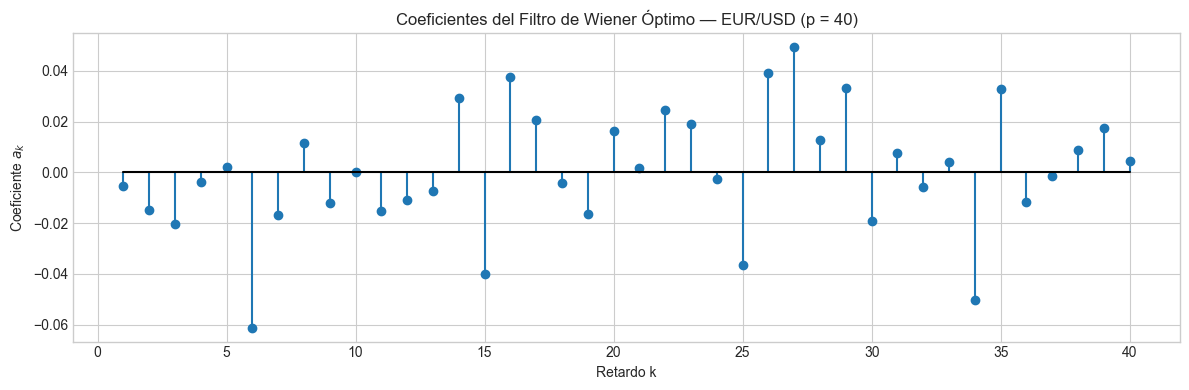

In [7]:
# ============================================================
# Reto – Diseño del Filtro de Wiener Óptimo (p = 40)
# ============================================================

p_eur = 40   # Orden del filtro: 40 días de historia para predecir el siguiente

# Estimación de la autocorrelación empírica
r_eur = estimar_autocorrelacion(x_eur, p_eur)

# Matriz de autocorrelación Toeplitz R_x (p × p)
R_eur = la.toeplitz(r_eur[:p_eur])

# Vector de correlación cruzada con el paso futuro r_x
r_vec_eur = r_eur[1:p_eur+1]

# Resolver las ecuaciones de Wiener-Hopf: R_x * a = r_x
coef_wiener_eur = np.linalg.solve(R_eur, r_vec_eur)

print("Coeficientes del Filtro de Wiener — EUR/USD (a_1 … a_40):")
print(np.round(coef_wiener_eur, 5))

# Gráfica de los coeficientes
plt.figure(figsize=(12, 4))
plt.stem(range(1, p_eur + 1), coef_wiener_eur,
         markerfmt='C0o', linefmt='C0-', basefmt='k-')
plt.title('Coeficientes del Filtro de Wiener Óptimo — EUR/USD (p = 40)')
plt.xlabel('Retardo k')
plt.ylabel('Coeficiente $a_k$')
plt.grid(True)
plt.tight_layout()
plt.show()

In [8]:
# ============================================================
# Reto – Predicción de los próximos 20 días
# ============================================================

dias_pred_eur = 20
x_pred_eur    = np.zeros(dias_pred_eur)

# Últimos p_eur días reales como condición inicial
historia_eur = list(x_eur[-p_eur:])

for i in range(dias_pred_eur):
    pred = np.dot(coef_wiener_eur, historia_eur[-p_eur:][::-1])
    x_pred_eur[i] = pred
    historia_eur.append(pred)

print("Rendimientos predichos del EUR/USD (media cero):")
print(np.round(x_pred_eur, 6))

Rendimientos predichos del EUR/USD (media cero):
[-0.005674 -0.027219 -0.120244  0.041486 -0.005384 -0.034706  0.013291
 -0.050311  0.128853  0.009679  0.014961 -0.074526 -0.021636 -0.059008
  0.152524 -0.027028  0.006103 -0.037043  0.087048  0.077838]


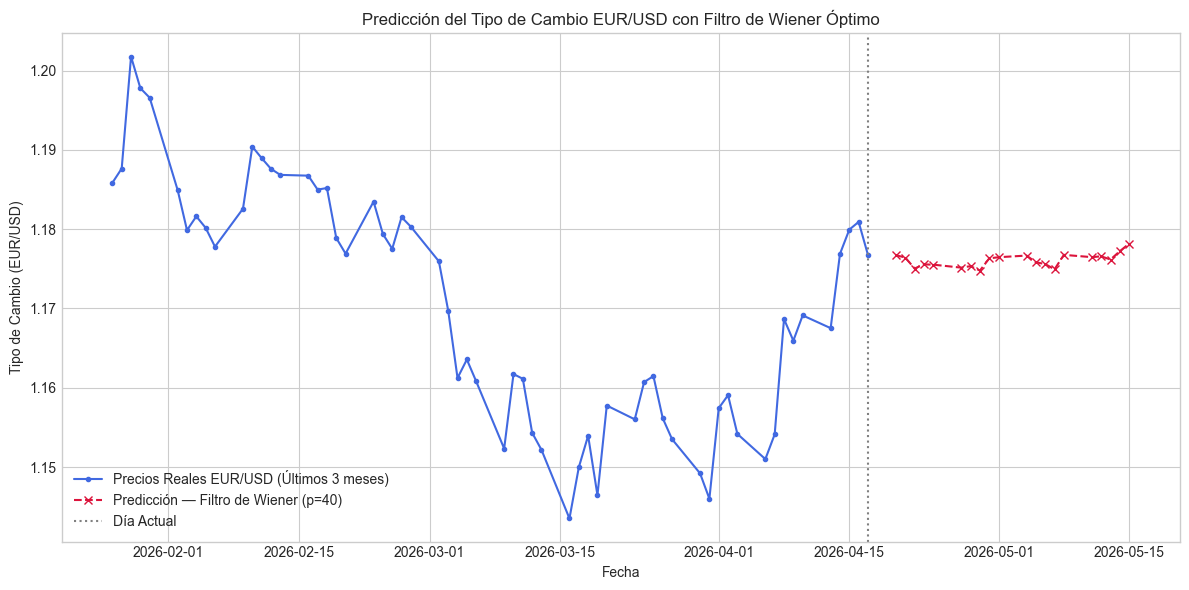


Último precio EUR/USD real:  1.17675

Día        Rend. pred. (%)    Precio proyectado
-----------------------------------------------
+1               -0.003063              1.17671
+2               -0.024608              1.17642
+3               -0.117632              1.17504
+4                0.044098              1.17556
+5               -0.002772              1.17552
+6               -0.032095              1.17515
+7                0.015902              1.17533
+8               -0.047699              1.17477
+9                0.131465              1.17632
+10               0.012291              1.17646
+11               0.017572              1.17667
+12              -0.071915              1.17582
+13              -0.019025              1.17560
+14              -0.056396              1.17494
+15               0.155136              1.17676
+16              -0.024417              1.17647
+17               0.008714              1.17657
+18              -0.034431              1.17617
+

In [9]:
# ============================================================
# Reto – Reconstrucción a precios y visualización final
# ============================================================

# Devolver la media a los rendimientos predichos
rend_pred_eur = x_pred_eur + media_eur

# Reconstruir precios usando el último valor real como semilla
precio_actual_eur    = float(precios_eur.iloc[-1])
precios_proy_eur     = precio_actual_eur * (1 + rend_pred_eur / 100).cumprod()

# Preparar fechas (últimos 3 meses ≈ 60 días hábiles)
dias_hist_eur  = 60
precios_rec    = precios_eur.iloc[-dias_hist_eur:]
fechas_rec     = precios_eur.index[-dias_hist_eur:]
fechas_fut_eur = pd.date_range(
    start=fechas_rec[-1] + pd.Timedelta(days=1),
    periods=dias_pred_eur, freq='B'
)

plt.figure(figsize=(12, 6))
plt.plot(fechas_rec, precios_rec.values,
         label='Precios Reales EUR/USD (Últimos 3 meses)',
         color='royalblue', marker='.', linewidth=1.5)
plt.plot(fechas_fut_eur, precios_proy_eur,
         label='Predicción — Filtro de Wiener (p=40)',
         color='crimson', marker='x', linestyle='--', linewidth=1.5)
plt.axvline(fechas_rec[-1], color='gray', linestyle=':', linewidth=1.5,
            label='Día Actual')
plt.title('Predicción del Tipo de Cambio EUR/USD con Filtro de Wiener Óptimo')
plt.xlabel('Fecha')
plt.ylabel('Tipo de Cambio (EUR/USD)')
plt.legend()
plt.tight_layout()
plt.show()

# Tabla de resultados
print(f"\nÚltimo precio EUR/USD real:  {precio_actual_eur:.5f}")
print(f"\n{'Día':<8} {'Rend. pred. (%)':>17} {'Precio proyectado':>20}")
print("-" * 47)
for i, (r, p) in enumerate(zip(rend_pred_eur, precios_proy_eur), 1):
    print(f"+{i:<7d} {r:>17.6f} {p:>20.5f}")

In [10]:
# ============================================================
# Reto – Tabla resumen de precios proyectados
# ============================================================

print(f"Último precio EUR/USD real:  {precio_actual_eur:.5f}\n")
print(f"{'Día hábil':<12} {'Rend. pred. (%)':>17} {'Precio proyectado (EUR/USD)':>28}")
print("-" * 59)
for i, (fecha, r, p) in enumerate(zip(fechas_fut_eur, rend_pred_eur, precios_proy_eur), 1):
    print(f"+{i:<2d}  {fecha.strftime('%Y-%m-%d'):<10} {r:>17.6f} {p:>28.5f}")

Último precio EUR/USD real:  1.17675

Día hábil      Rend. pred. (%)  Precio proyectado (EUR/USD)
-----------------------------------------------------------
+1   2026-04-20         -0.003063                      1.17671
+2   2026-04-21         -0.024608                      1.17642
+3   2026-04-22         -0.117632                      1.17504
+4   2026-04-23          0.044098                      1.17556
+5   2026-04-24         -0.002772                      1.17552
+6   2026-04-27         -0.032095                      1.17515
+7   2026-04-28          0.015902                      1.17533
+8   2026-04-29         -0.047699                      1.17477
+9   2026-04-30          0.131465                      1.17632
+10  2026-05-01          0.012291                      1.17646
+11  2026-05-04          0.017572                      1.17667
+12  2026-05-05         -0.071915                      1.17582
+13  2026-05-06         -0.019025                      1.17560
+14  2026-05-07        